# Differential Equations for Machine Learning
## Notebook 02 — Systems of ODEs and the Lorenz System

### Objective

In Notebook 01, we studied a single ODE:

    dy/dt = 2y

Now we move to systems of differential equations.

We will learn:

1. What a system of ODEs is
2. How multiple variables can depend on each other
3. How to represent an ODE system in Python
4. Numerical integration with `solve_ivp`
5. The Lorenz system
6. Phase space
7. Chaotic behavior
8. Sensitivity to initial conditions

The Lorenz system will eventually become our first serious PINN problem.

# 1. From One Variable to Multiple Variables

Previously we had:

    dy/dt = 2y

There was only one unknown variable:

    y(t)

Now imagine that we have three variables:

    x(t)
    y(t)
    z(t)

and each variable changes according to the others.

For example:

    dx/dt = y
    dy/dt = -x

This is called a system of ordinary differential equations.

We can think of the complete state as a vector:

    u(t) = [x(t), y(t)]

or:

    u(t) = [x(t), y(t), z(t)]

The differential equation then becomes:

    du/dt = f(t, u)

This form is extremely important because this is exactly the form expected
by numerical ODE solvers such as `solve_ivp`.

# 2. A Simple Two-Variable System

Consider:

    dx/dt = y

    dy/dt = -x

Notice something interesting.

The change in `x` depends on `y`.

The change in `y` depends on `x`.

Therefore the two variables are coupled.

This system produces oscillatory motion.

We can think of:

    x → affects y
    y → affects x

This kind of coupled system appears throughout physics and engineering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
def oscillator(t, state):
    """
    Two-variable system:

        dx/dt = y
        dy/dt = -x

    Parameters
    ----------
    t : float
        Current time.

    state : array-like
        Current state [x, y].

    Returns
    -------
    list
        [dx/dt, dy/dt]
    """

    x, y = state
    
    dx_dt = y
    dy_dt = -x

    return [dx_dt, dy_dt]

# 3. Initial Conditions for a System

For a single ODE we needed:

    y(0) = y₀

For a system, we need the initial value of every variable.

For example:

    x(0) = 1
    y(0) = 0

So our initial state is:

    [1, 0]

This completely specifies where the simulation starts.

In [4]:
initial_state = [1, 0]

solution = solve_ivp(
    oscillator,
    (0, 20),
    initial_state,
    t_eval=np.linspace(0, 20, 1000)
)

print("Number of time points:", len(solution.t))
print("First state:", solution.y[:, 0])
print("Last state:", solution.y[:, -1])

Number of time points: 1000
First state: [1. 0.]
Last state: [ 0.40273088 -0.91506103]


# 4. Understanding `solution.y`

For a system containing two variables:

    x(t)
    y(t)

`solution.y` has two rows.

Conceptually:

              t₀    t₁    t₂    t₃    ...
    x(t)      x₀    x₁    x₂    x₃    ...
    y(t)      y₀    y₁    y₂    y₃    ...

Therefore:

    solution.y[0]

contains all x values.

And:

    solution.y[1]

contains all y values.

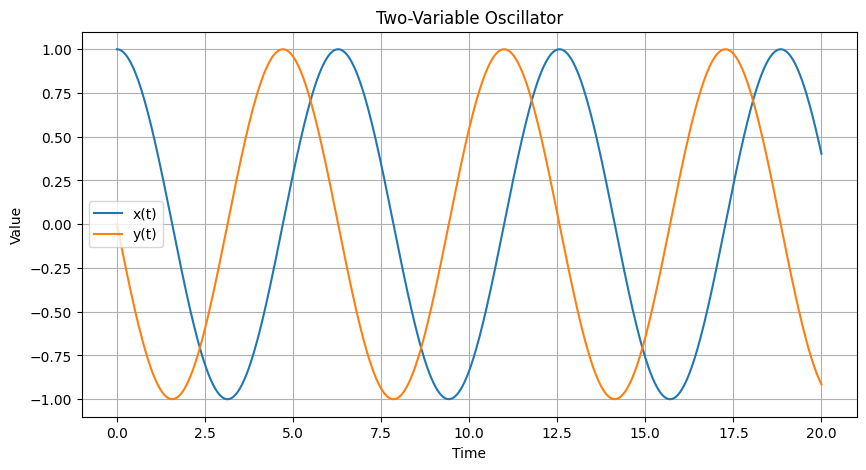

In [5]:
t = solution.t

x = solution.y[0]
y = solution.y[1]

plt.figure(figsize=(10, 5))

plt.plot(t, x, label="x(t)")
plt.plot(t, y, label="y(t)")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Two-Variable Oscillator")
plt.grid(True)
plt.legend()

plt.show()

# 5. Phase Space

Instead of plotting variables against time, we can plot one variable
against another.

For our system:

    x(t)
    y(t)

we plot:

    y vs x

This is called a phase-space plot.

It shows the trajectory of the system's state.

For the oscillator, the trajectory forms a closed curve.

This becomes extremely useful for understanding dynamical systems.

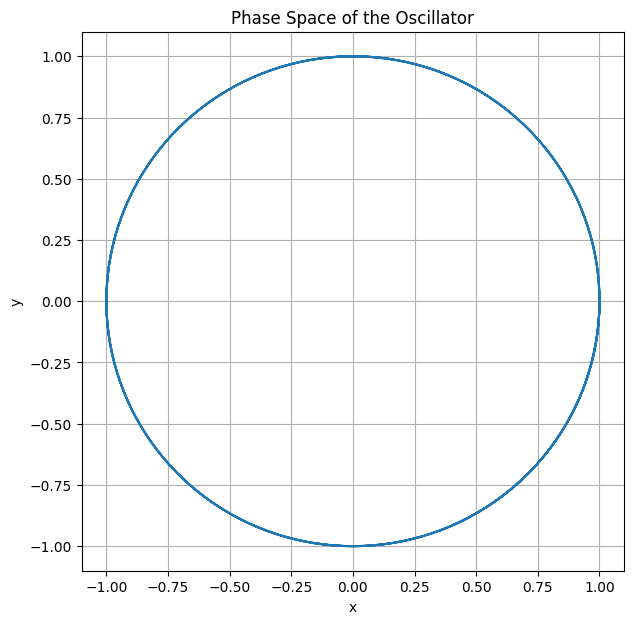

In [6]:
plt.figure(figsize=(7, 7))

plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase Space of the Oscillator")
plt.grid(True)

plt.show()